Goal:
To manually compute the output of a simple Multi-Layer Perceptron with:

2 input features
1 hidden layer with 2 neurons
1 output neuron
using forward propagation.



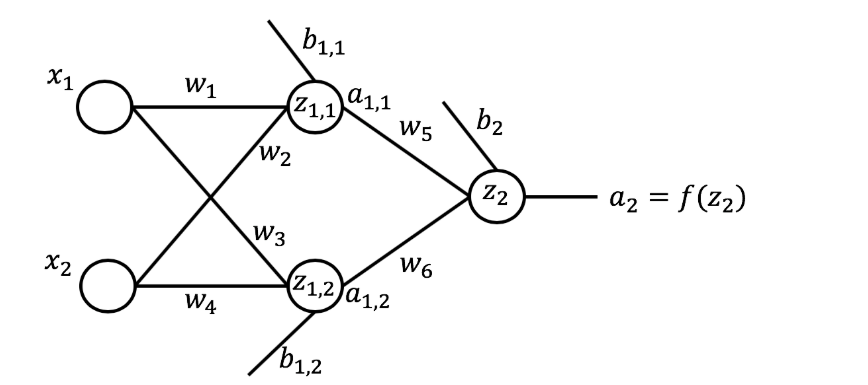

In [ ]:
import numpy as np
#NumPy is used for: Mathematical operations,Exponential function and Working with arrays

# Parameters (Weights & Biases)
weights = np.around(np.random.uniform(size=6), decimals=2)
biases = np.around(np.random.uniform(size=3), decimals=2)

#These are the input features given to the network.
x_1 = 0.5
x_2 = 0.85

#Hidden Layer – Weighted Sum (z-values)
z_11 = x_1 * weights[0] + x_2 * weights[1] + biases[0]
z_12 = x_1 * weights[2] + x_2 * weights[3] + biases[1]

#Hidden Layer – Activation (a-values)
a_11 = 1.0 / (1.0 + np.exp(-z_11))
a_12 = 1.0 / (1.0 + np.exp(-z_12))

#Output Layer – Weighted Sum
z_2 = a_11 * weights[4] + a_12 * weights[5] + biases[2]

#Output Layer – Activation
a_2 = 1.0 / (1.0 + np.exp(-z_2))


Forward Propagation



1.   Multiply inputs by weights
2.   Add bias → get z
3. Apply activation → get a
4. Pass a to next layer
5. Repeat until output layer

 manually demonstrate how a neural network is built and how a single neuron computes its output using forward propagation.

In [ ]:
import numpy as np

# This function creates a neural network by defining:
# - number of inputs
# - number of hidden layers
# - number of nodes in each hidden layer
# - number of nodes in the output layer

def initialize_network(num_inputs, num_hidden_layers, num_nodes_hidden, num_nodes_output):

    # This stores the number of nodes in the previous layer.
    # Each node in the current layer will have one weight for each node in the previous layer.
    # Initially, the previous layer is the input layer.
    num_nodes_previous = num_inputs

    # Create empty network dictionary.
    # This will store:
    # - layer type (hidden or output)
    # - nodes in each layer
    # - weights and bias for each node
    network = {}

    # Loop through all layers.
    # +1 is used to include the output layer in the loop.
    for layer in range(num_hidden_layers + 1):

        # Decide layer type and number of nodes
        if layer == num_hidden_layers:
            # Last layer is the output layer
            layer_name = 'output'
            num_nodes = num_nodes_output
        else:
            # Hidden layers are named layer_1, layer_2, etc.
            layer_name = 'layer_{}'.format(layer + 1)
            num_nodes = num_nodes_hidden[layer]

        # Create dictionary for the current layer
        network[layer_name] = {}

        # Loop through nodes in the layer
        for node in range(num_nodes):

            # Create node names: node_1, node_2, etc.
            node_name = 'node_{}'.format(node + 1)

            # Initialize weights and bias for each node
            # Each node gets:
            # - weights: number of weights equals number of nodes in the previous layer
            # - bias: one bias value
            network[layer_name][node_name] = {
                'weights': np.around(np.random.uniform(size=num_nodes_previous), decimals=2),
                'bias': np.around(np.random.uniform(size=1), decimals=2),
            }

        # Update previous layer node count
        # Current layer becomes previous layer for the next iteration
        num_nodes_previous = num_nodes

    # Return the fully initialized network
    return network



# Create a small neural network
# 5 input features
# 3 hidden layers with 3, 2, and 3 nodes
# 1 output node
small_network = initialize_network(5, 3, [3, 2, 3], 1)



# Weighted Sum Function
# This function computes the weighted sum:
# z = sum(x_i * w_i) + b
def compute_weighted_sum(inputs, weights, bias):
    return np.sum(inputs * weights) + bias


# Generate input values
# Generates 5 random input values between 0 and 1
# Random seed ensures the same values are generated every time
np.random.seed(12)
inputs = np.around(np.random.uniform(size=5), decimals=2)
print("Inputs to the network:", inputs)



# Access weights and bias of a specific node
# This accesses the weights and bias of the first node in the first hidden layer
node_weights = small_network['layer_1']['node_1']['weights']
node_bias = small_network['layer_1']['node_1']['bias']



# Compute weighted sum for the node
weighted_sum = compute_weighted_sum(inputs, node_weights, node_bias)



# Activation Function (Sigmoid)
# Converts weighted sum into a value between 0 and 1
def node_activation(weighted_sum):
    return 1.0 / (1.0 + np.exp(-weighted_sum))



# Compute output of the node
# inputs → weighted sum → sigmoid activation
node_output = node_activation(
    compute_weighted_sum(inputs, node_weights, node_bias)
)



# Print the node output
print(
    'The output of the first node in the hidden layer is {}'.format(
        np.around(node_output[0], decimals=4)
    )
)


Inputs to the network: [0.15 0.74 0.26 0.53 0.01]
The output of the first node in the hidden layer is 0.7412


This code implements forward propagation in a neural network. It takes input values, passes them through each layer of the network, computes the weighted sum and sigmoid activation for every node, uses the outputs of one layer as inputs to the next, and finally returns the output layer values as the network’s prediction.

In [ ]:
# This function performs forward propagation through the entire neural network
# to compute the final output (prediction).

def forward_propagate(network, inputs):

    # Convert inputs to list format.
    # These inputs are fed to the first hidden layer.
    layer_inputs = list(inputs)

    # Loop through each layer in the network
    for layer in network:

        # Contains all nodes in the current layer.
        # Each node has its own weights and bias.
        layer_data = network[layer]

        # List to store outputs of all neurons in this layer
        layer_outputs = []

        # Loop through each node in the layer
        for layer_node in layer_data:

            # Get weights and bias of the node
            node_data = layer_data[layer_node]

            # Compute weighted sum and apply sigmoid activation
            node_output = node_activation(
                compute_weighted_sum(
                    layer_inputs,
                    node_data['weights'],
                    node_data['bias']
                )
            )

            # Store node output
            layer_outputs.append(float(np.around(node_output[0], decimals=4)))


        # Print outputs of hidden layers only
        if layer != 'output':
            print(
                'The outputs of the nodes in hidden layer number {} is {}'.format(
                    layer.split('_')[1],
                    layer_outputs
                )
            )

        # Outputs of current layer become inputs to the next layer
        layer_inputs = layer_outputs

    # Final outputs come from the output layer
    network_predictions = layer_outputs
    return network_predictions


# Call the function for a single-output network
predictions = forward_propagate(small_network, inputs)
print(
    'The predicted value by the network for the given input is {}'.format(
        np.around(predictions[0], decimals=4)
    )
)

# Example with multiple output neurons
my_network = initialize_network(5, 3, [2, 3, 2], 3)
inputs = np.around(np.random.uniform(size=5), decimals=2)
predictions = forward_propagate(my_network, inputs)
print('The predicted values by the network for the given input are {}'.format(predictions))


The outputs of the nodes in hidden layer number 1 is [0.7412, 0.7954, 0.7447]
The outputs of the nodes in hidden layer number 2 is [0.774, 0.8577]
The outputs of the nodes in hidden layer number 3 is [0.7138, 0.7547, 0.6774]
The predicted value by the network for the given input is 0.6227
The outputs of the nodes in hidden layer number 1 is [0.8857, 0.8889]
The outputs of the nodes in hidden layer number 2 is [0.7822, 0.6965, 0.7411]
The outputs of the nodes in hidden layer number 3 is [0.868, 0.881]
The predicted values by the network for the given input are [0.8952, 0.8222, 0.8035]


## Forward Propagation and Backpropagation

During **forward propagation**, the network computes the **weighted sum of inputs** and applies an **activation function** (such as **sigmoid**) to produce a prediction.  
The prediction is then compared with the **true output** using a **loss function** to compute the error.

**Backpropagation** uses this error to compute **gradients** and update the **weights** in a direction that reduces the loss, so that future predictions become more accurate.

---

## XOR (Exclusive OR)

**XOR** stands for **Exclusive OR**.

- Output is **1** when the two inputs are **different**
- Output is **0** when the two inputs are **the same**

### XOR Truth Table

- `(0, 0) → 0`
- `(1, 1) → 0`
- `(0, 1) → 1`
- `(1, 0) → 1`

---

## Why XOR Needs a Multi-Layer Perceptron

When plotted, there is **no single linear decision boundary** that can separate the points with output **1** from the points with output **0**.

Therefore:
- XOR is **not linearly separable**
- It **cannot be solved by a single neuron**

A **Multi-Layer Perceptron (MLP)** with at least **one hidden layer** can learn a **non-linear decision boundary**, which is why it is used to solve the XOR problem.


# **Activation function and vanishing graident**

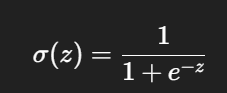

In [ ]:
import numpy as np
# NumPy is a math library used for vectors, matrices, arrays,
# and mathematical operations.
# "np" is just a short nickname for numpy.

import matplotlib.pyplot as plt
# Matplotlib is used for plotting graphs such as line plots and scatter plots.
# pyplot is a module inside matplotlib used for drawing graphs.
# Lines starting with # are comments and are ignored by Python.

def sigmoid(z):
    # This function takes input z and applies the sigmoid function
    return 1 / (1 + np.exp(-z))   # Output is between 0 and 1

def sigmoid_derivative(z):
    # This function computes the derivative of the sigmoid output with respect to z
    # It tells how sensitive the output is to changes in z
    return sigmoid(z) * (1 - sigmoid(z))

def relu(z):
    # This function applies the ReLU activation function
    # If z is negative, it returns 0; otherwise, it returns z
    return np.maximum(0, z)
